# ex03_lti_duct
Interactive notebook version of the Python example.
Edit parameters and rerun cells to explore the model behavior.

## MATLAB Example Structure
- The high-order LTI model (acoustical duct) with coloured process noise
- High-order identification experiment
- Identification of the model in open loop
- Verification results
- Identification results
- Lower-order identification experiment
- Identification of the model in open loop
- Verification results
- Identification results

## Imports

In [8]:
from __future__ import annotations
import numpy as np
from _common import (
    estimate_varmax_abcdk,
    estimate_varx_abcdk,
    print_case_summary,
    simulate_system,
    state_space_model,
    vaf_percent,
)
from control import matlab as ml
from pbsid.plotting import plot_bode_magnitude_grid, plot_pole_map
from scipy.signal import lfilter
from snr import snr_db

## The High-Order LTI Model (Acoustical Duct) With Coloured Process Noise
Define the high-order duct denominator and disturbance models used in the MATLAB example.

In [7]:
ts = 0.001
a_den = np.array(
    [
        1.0,
        -1.8937219532483,
        0.92020408176247,
        8.4317527635809e-13,
        -6.9870644340972e-13,
        3.2703011891141e-13,
        -2.8053825784320e-14,
        -4.8518619047975e-13,
        9.0515016323085e-13,
        -8.9573340462955e-13,
        6.2104932381850e-13,
        -4.0655443037130e-13,
        3.8448359402553e-13,
        -4.9321540807220e-13,
        5.3571245452629e-13,
        -6.7043859898372e-13,
        6.5050860651120e-13,
        0.66499999999978,
        -1.2593250989101,
        0.61193571437226,
    ],
    dtype=np.float64,
 )
b_u = np.array(
    [
        0.0,
        -5.6534330123106e-6,
        5.6870704280702e-6,
        7.7870811926239e-3,
        1.3389477125431e-3,
        -9.1260667240191e-3,
        1.4435759589218e-8,
        -1.2021568096247e-8,
        -2.2746529807395e-9,
        6.3067990166664e-9,
        9.1305924779895e-10,
        -7.5200613526843e-9,
        1.9549739577695e-9,
        1.3891832078608e-8,
        -1.6372496840947e-8,
        9.0003511972213e-3,
        -1.9333235957678e-3,
        -7.0669966879457e-3,
        -3.7850561971775e-6,
        3.7590122810601e-6,
    ],
    dtype=np.float64,
 )
b_e = np.array(
    [
        0.0,
        -5.65645330123106e-6,
        5.345344280702e-6,
        7.45341926239e-3,
        2.3389477125431e-3,
        -9.5480667240191e-3,
        1.545435759589218e-8,
        -1.2343468096247e-8,
        -2.534549807395e-9,
        4.454930166664e-9,
        9.342424779895e-10,
        -7.2342313526843e-9,
        1.9549739577695e-9,
        1.564565078608e-8,
        -3.1272496840947e-8,
        9.345511972213e-3,
        -1.876875957678e-3,
        -6.0669966879457e-3,
        -3.54561971775e-6,
        3.7590122810601e-6,
    ],
    dtype=np.float64,
 )


[ex03-high-order-varx]
SNR (dB): [21.6]
VAF (%): [99.41]
Estimated poles: [-0.8793+0.3625j -0.8793-0.3625j -0.4163+0.8555j -0.4163-0.8555j
 -0.087 +0.954j  -0.087 -0.954j   0.9656+0.1725j  0.9656-0.1725j
  0.9219+0.162j   0.9219-0.162j   0.8307+0.5146j  0.8307-0.5146j
  0.315 +0.j      0.2206+0.8453j  0.2206-0.8453j  0.5876+0.7787j
  0.5876-0.7787j  0.4034+0.8647j  0.4034-0.8647j]

[ex03-high-order-varmax]
SNR (dB): [21.6]
VAF (%): [100.]
Estimated poles: [-0.91  +0.3529j -0.91  -0.3529j -0.9731+0.j     -0.7188+0.6562j
 -0.7188-0.6562j -0.435 +0.8743j -0.435 -0.8743j -0.0899+0.9721j
 -0.0899-0.9721j  0.2676+0.9374j  0.2676-0.9374j  0.5881+0.7791j
  0.5881-0.7791j  0.8303+0.5137j  0.8303-0.5137j  0.9598+0.1793j
  0.9598-0.1793j  0.9463+0.1536j  0.9463-0.1536j]
Sample time used: 0.001


## High-Order Identification Experiment
Simulate the high-order open-loop experiment for the acoustical duct example.

In [ ]:
n_samples = 5000
rng = np.random.default_rng(103)
r = np.sign(rng.standard_normal(n_samples)).astype(np.float64)
e = 0.1 * rng.standard_normal(n_samples)
y0 = lfilter(b_u, a_den, r)
y = y0 + lfilter(b_e, a_den, e)

## Identification Of The Model In Open Loop
Estimate high-order VARX and PBSIDopt models for the open-loop duct data.

In [ ]:
n = 19
f = 30
p = 30
u2 = r.reshape(-1, 1)
y2 = y.reshape(-1, 1)
y0_2 = y0.reshape(-1, 1)
_, ai, bi, ci, di, _, _, _ = estimate_varx_abcdk(u2, y2, n, f, p)
_, av, bv, cv, dv, _ = estimate_varmax_abcdk(
    u2, y2, n, f, p, method="gradient", tol=1e-4
)

## Verification Results
High-order verification against the identified models.

In [ ]:
yi, _ = simulate_system(state_space_model(ai, bi, ci, di, ts), u2, dt=ts)
yv, _ = simulate_system(state_space_model(av, bv, cv, dv, ts), u2, dt=ts)
print_case_summary("ex03-high-order-varx", snr_db(y2, y0_2), vaf_percent(y0_2, yi), ai)
print_case_summary("ex03-high-order-varmax", snr_db(y2, y0_2), vaf_percent(y0_2, yv), av)
print(f"Sample time used: {ts}")

## Identification Results
High-order pole and Bode comparisons are plotted below. The lower-order MATLAB workflow is still exposed as pending sections further down.

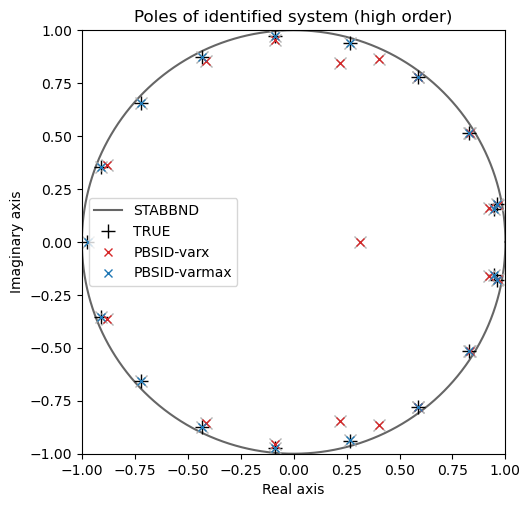

In [9]:
plot_pole_map(
    np.roots(a_den),
    [
        ("PBSID-varx", np.linalg.eigvals(ai), "x", "tab:red"),
        ("PBSID-varmax", np.linalg.eigvals(av), "x", "tab:blue"),
    ],
    "Poles of identified system (high order)",
)

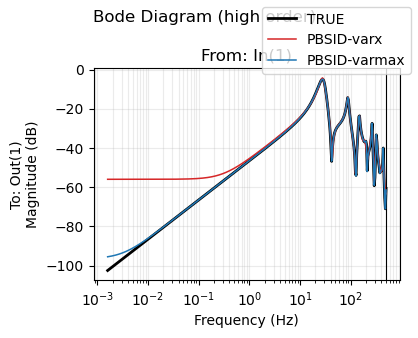

In [10]:
w = np.logspace(-2, np.log10(np.pi / ts), 400)
plot_bode_magnitude_grid(
    ml.tf(b_u, a_den, ts),
    [
        ("PBSID-varx", ml.ss(ai, bi, ci, di, ts), "tab:red"),
        ("PBSID-varmax", ml.ss(av, bv, cv, dv, ts), "tab:blue"),
    ],
    "Bode Diagram (high order)",
    sample_time=ts,
    w=w,
)

## Lower-Order Identification Experiment
MATLAB continues with a lower-order identification workflow after the high-order case. This notebook now exposes that section boundary explicitly, even though the lower-order executable cells are still pending.

## Identification Of The Model In Open Loop
The lower-order open-loop identification stage from MATLAB remains to be split into its own executable notebook cells.

## Verification Results
The lower-order verification stage from MATLAB is not yet ported into a separate executable notebook workflow.